In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/classes.txt
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_7209.jpeg
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_6978.jpeg
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_9299.jpeg
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_9032.txt
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_8733.txt
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_6120.txt
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_4362.txt
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_9055.txt
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_2495.txt
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_9095.txt
/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agr

In [2]:
!pip install ultralytics -q
from ultralytics import YOLO
import os
import glob
import random
import shutil
import cv2
import matplotlib.pyplot as plt
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
project_dir = "/kaggle/working/Crop_vs_Weed_Detection"

os.makedirs(project_dir, exist_ok=True)

print("Project folder:", project_dir)

Project folder: /kaggle/working/Crop_vs_Weed_Detection


In [6]:
dataset_path = "/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data"

In [8]:
images = glob.glob(dataset_path + "/*.jpeg")

print("Total images:", len(images))

Total images: 1300


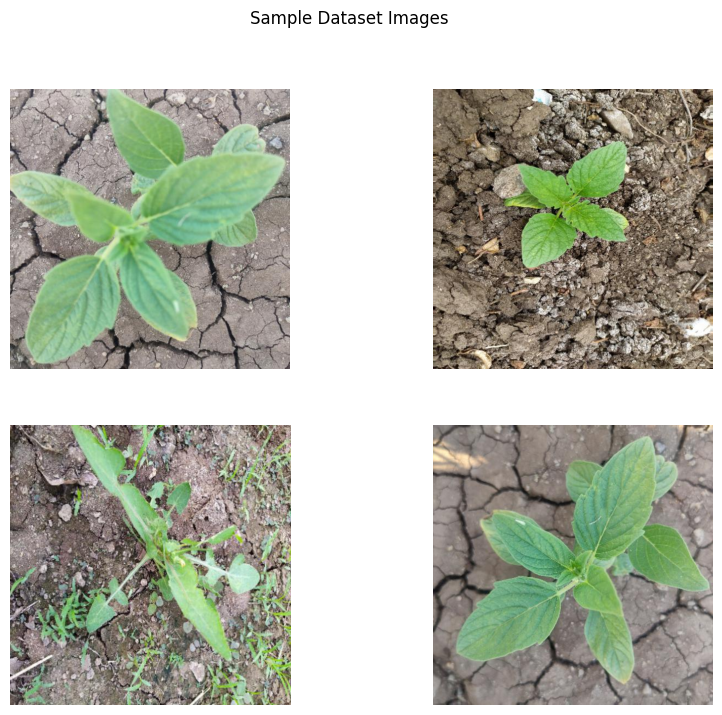

In [9]:
sample_images = random.sample(images, 4)

plt.figure(figsize=(10,8))

for i,img_path in enumerate(sample_images):
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Sample Dataset Images")
plt.show()

In [10]:
random.shuffle(images)

split_index = int(0.8 * len(images))

train_images = images[:split_index]
val_images = images[split_index:]

print("Training images:", len(train_images))
print("Validation images:", len(val_images))

Training images: 1040
Validation images: 260


In [11]:
base_dir = "/kaggle/working/dataset"

train_img = f"{base_dir}/images/train"
val_img = f"{base_dir}/images/val"
train_lbl = f"{base_dir}/labels/train"
val_lbl = f"{base_dir}/labels/val"

os.makedirs(train_img, exist_ok=True)
os.makedirs(val_img, exist_ok=True)
os.makedirs(train_lbl, exist_ok=True)
os.makedirs(val_lbl, exist_ok=True)

In [12]:
def copy_files(image_list, img_dest, lbl_dest):
    
    for img_path in image_list:
        
        filename = os.path.basename(img_path)
        label_path = img_path.replace(".jpeg",".txt")
        
        shutil.copy(img_path, os.path.join(img_dest,filename))
        
        if os.path.exists(label_path):
            shutil.copy(label_path,
                        os.path.join(lbl_dest,filename.replace(".jpeg",".txt")))

copy_files(train_images,train_img,train_lbl)
copy_files(val_images,val_img,val_lbl)

print("Dataset prepared")

Dataset prepared


In [14]:
data_yaml = f"""
path: {base_dir}
train: images/train
val: images/val

names:
  0: crop
  1: weed
"""

with open("/kaggle/working/data.yaml","w") as f:
    f.write(data_yaml)

print("data.yaml created")

data.yaml created


In [15]:
model = YOLO("yolov8n.pt")

model.train(
    data="/kaggle/working/data.yaml",
    epochs=30,
    imgsz=512,
    batch=16,
    name="crop_weed_detector"
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=crop_weed_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fef30620650>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [17]:
summary = {
    "Metric":["Precision","Recall","mAP@50","mAP@50-95"],
    "Score":[
        metrics.box.mp,
        metrics.box.mr,
        metrics.box.map50,
        metrics.box.map
    ]
}

df = pd.DataFrame(summary)

df

,Metric,Score
0,Precision,0.825601
1,Recall,0.760598
2,mAP@50,0.821269
3,mAP@50-95,0.546602


In [18]:
model.predict(
    source="/kaggle/working/dataset/images/val",
    conf=0.25,
    save=True
)


image 1/260 /kaggle/working/dataset/images/val/agri_0_1026.jpeg: 512x512 1 crop, 6.6ms
image 2/260 /kaggle/working/dataset/images/val/agri_0_1041.jpeg: 512x512 1 crop, 5.9ms
image 3/260 /kaggle/working/dataset/images/val/agri_0_1082.jpeg: 512x512 2 crops, 5.7ms
image 4/260 /kaggle/working/dataset/images/val/agri_0_1166.jpeg: 512x512 2 weeds, 5.8ms
image 5/260 /kaggle/working/dataset/images/val/agri_0_1174.jpeg: 512x512 2 crops, 5.6ms
image 6/260 /kaggle/working/dataset/images/val/agri_0_1210.jpeg: 512x512 1 weed, 5.6ms
image 7/260 /kaggle/working/dataset/images/val/agri_0_1221.jpeg: 512x512 3 crops, 5.6ms
image 8/260 /kaggle/working/dataset/images/val/agri_0_129.jpeg: 512x512 1 crop, 5.6ms
image 9/260 /kaggle/working/dataset/images/val/agri_0_131.jpeg: 512x512 2 crops, 1 weed, 5.7ms
image 10/260 /kaggle/working/dataset/images/val/agri_0_1351.jpeg: 512x512 1 crop, 5.6ms
image 11/260 /kaggle/working/dataset/images/val/agri_0_1612.jpeg: 512x512 1 weed, 5.6ms
image 12/260 /kaggle/working/

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crop', 1: 'weed'}
 obb: None
 orig_img: array([[[ 49,  65,  81],
         [ 56,  72,  88],
         [ 57,  73,  89],
         ...,
         [179, 207, 224],
         [179, 209, 226],
         [178, 208, 225]],
 
        [[ 98, 114, 130],
         [100, 116, 132],
         [ 98, 114, 130],
         ...,
         [146, 174, 191],
         [139, 169, 186],
         [134, 164, 181]],
 
        [[100, 116, 132],
         [101, 117, 133],
         [103, 119, 135],
         ...,
         [178, 205, 225],
         [182, 212, 231],
         [181, 211, 230]],
 
        ...,
 
        [[ 11,  11,  29],
         [  9,  11,  29],
         [  2,   5,  20],
         ...,
         [ 99, 112, 128],
         [ 98, 111, 127],
         [100, 113, 129]],
 
        [[ 23,  21,  40],
         [ 27,  27,  45],
         [ 26,  26,  42],
         ...,
         

In [23]:
model.predict(
    source="/kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_1094.jpeg",
    conf=0.25,
    save=True
)


image 1/1 /kaggle/input/datasets/utsadas108/crop-vs-weed-datasets/agri_data/data/agri_0_1094.jpeg: 512x512 1 crop, 7.5ms
Speed: 1.8ms preprocess, 7.5ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /kaggle/working/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crop', 1: 'weed'}
 obb: None
 orig_img: array([[[186, 193, 196],
         [190, 197, 200],
         [185, 193, 193],
         ...,
         [ 75,  81,  86],
         [ 82,  86,  91],
         [ 72,  76,  81]],
 
        [[186, 194, 194],
         [190, 198, 198],
         [184, 192, 192],
         ...,
         [ 65,  71,  76],
         [ 71,  75,  80],
         [ 80,  84,  89]],
 
        [[184, 195, 193],
         [187, 198, 195],
         [180, 191, 188],
         ...,
         [ 60,  66,  71],
         [ 68,  72,  77],
         [ 82,  86,  91]],
 
        ...,
 
        [[119, 138, 153],
         [131, 150, 165],
         [116, 137, 152],
         ...,
         [ 99, 125, 142],
         [117, 141, 161],
         [117, 138, 159]],
 
        [[122, 141, 156],
         [129, 148, 163],
         [115, 136, 151],
         ...,
         

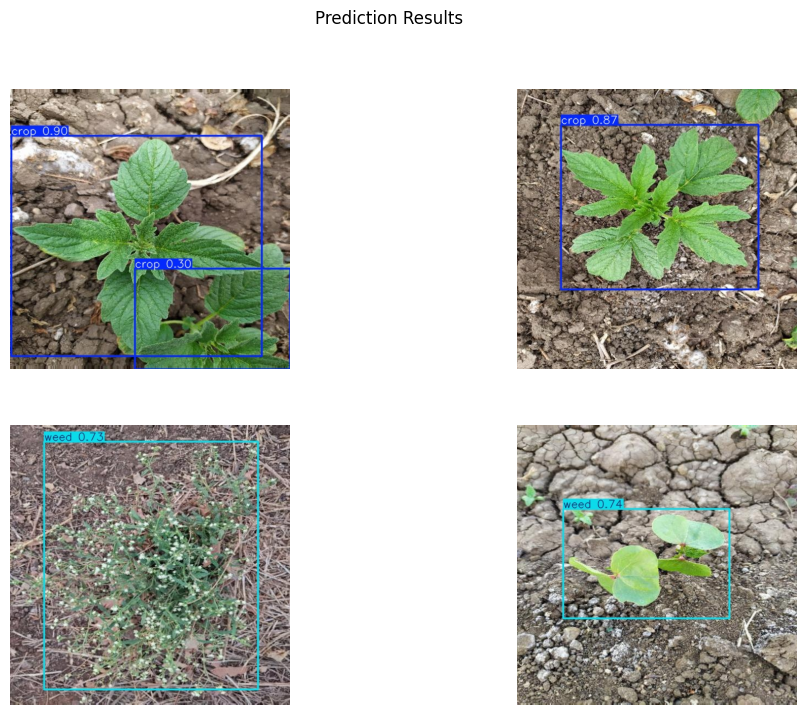

In [30]:
pred_images = glob.glob("/kaggle/working/runs/detect/predict/*.jpg")

plt.figure(figsize=(12,8))

for i,img_path in enumerate(pred_images[108:112]):
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Prediction Results")
plt.show()

In [31]:
results_dir = project_dir + "/results"

os.makedirs(results_dir, exist_ok=True)

In [32]:
val_folder = sorted(glob.glob("/kaggle/working/runs/detect/val*"))[-1]

files = [
"confusion_matrix.png",
"PR_curve.png",
"F1_curve.png",
"results.png"
]

for f in files:
    
    src = os.path.join(val_folder,f)
    dst = os.path.join(results_dir,f)
    
    if os.path.exists(src):
        shutil.copy(src,dst)

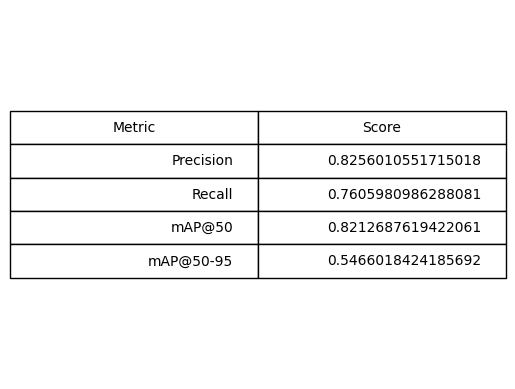

In [33]:
fig, ax = plt.subplots()

ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc="center"
)

table.scale(1,2)

plt.savefig(results_dir + "/metrics_summary.png")
plt.show()